# CGAN 
Nama : Fransciska Olivia Putri Warae

NIM : 2802516895

Video Penjelasan : https://drive.google.com/file/d/12M1tSwRl-61CgRPIKSx3M3SLcN2mUARK/view?usp=share_link

video keseluruhan : https://drive.google.com/file/d/1WM8lsn5gnK0iXPB7TgWaSl8GyV5lyqZt/view?usp=sharing

Saya menggunakan Data D Car Plane yang ada di version2

# POIN A : Cara Kerja GAN

Generative Adversarial Network (GAN) arsitektur deep learning yang terdiri dari dua komponen utama, yaitu Generator dan Discriminator.

Pada tahap awal, Generator menerima random noise sebagai input. Noise adalah nilai acak yang kemudian diproses oleh Generator untuk menghasilkan *fake image* yang menyerupai data asli pada training set.

Selanjutnya, gambar hasil Generator dan gambar asli dari dataset dimasukkan ke dalam Discriminator. Discriminator bertugas untuk melakukan klasifikasi apakah gambar yang diterima merupakan gambar real (asli) atau hasil generator.

Proses train berjalan secara *opposite* dimana generator berusaha menghasilkan gambar yang semakin realistis agar dapat menipu diskriminator, sedangkan diskriminator berusaha meningkatkan kemampuannya dalam membedakan gambar asli dan gambar palsu.

Ketika diskriminator berhasil mendeteksi gambar palsu, maka kesalahan akan dipakai untuk memperbaiki generatornya. Sebaliknya, kalau generator berhasil menghasilkan gambar yang sulit dibedakan dari gambar asli maka diskriminator akan dipaksa terus belajar untuk meningkatkan akurasinya.

Proses ini dilakukan berulang kali hingga kondisinya seimbang. Kondisi seimbang yaitu ketika generator dapat menghasilkan gambar yang sangat mirip dengan data asli dan diskriminator sulit untuk membedakan gambar real dan fake. Pada kondisi tersebut, Generator telah mempelajari distribusi data sehingga dapat digunakan untuk menghasilkan citra baru yang realistis.


# Fungsi Objektif GAN
Fungsi objektifnya:

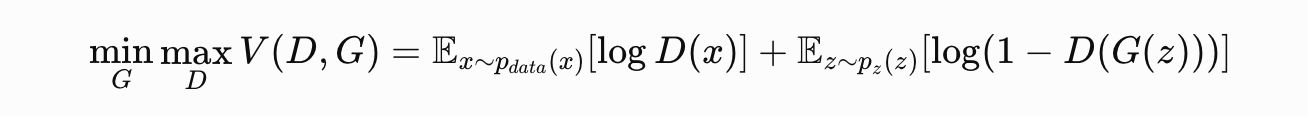

x = data asli dataset

z = random noise

G(z) = gambar hasil Generator

D(x) = probabilitas data asli

D(G(z)) = probabilitas gambar palsu dianggap asli

# Tujuan Diskriminator
Discriminator ingin:

memberikan nilai mendekati 1 untuk gambar asli

memberikan nilai mendekati 0 untuk gambar palsu

Sehingga fungsi loss Discriminator adalah:

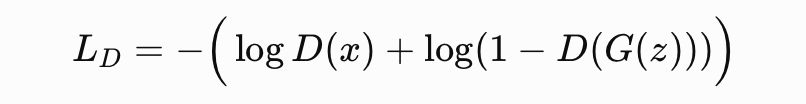

Semakin kecil loss, semakin baik kemampuan Discriminator membedakan gambar real dan fake.

# Tujuan Generator

Generator berusaha menipu Discriminator agar gambar palsu dianggap asli.

Loss Generator:

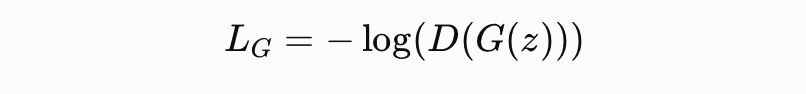

Generator akan terus memperbaiki parameter jaringan sehingga nilai:
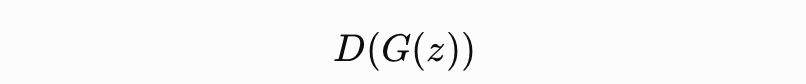

semakin mendekati 1.

# Alur Kerja GAN
1. Random noise diberikan input ke Generator.
2. Generator akan menghasilkan fake image.
3. Fake image dan real image dari dataset diberikan ke Discriminator.
4. Discriminator menentukan apakah gambar tersebut real atau fake.
5. Error dari Discriminator digunakan untuk memperbarui parameter Generator dan Discriminator.
6. Proses diulang sampai Generator mampu menghasilkan gambar yang menyerupai data asli.

# Kesimpulan
GAN bekerja dengan mekanisme kompetitif antara Generator dan Discriminator. Generator berusaha menghasilkan gambar yang realistis dari random noise, sedangkan Discriminator berusaha membedakan gambar asli dan gambar palsu. Melalui proses adversarial yang berulang, Generator secara bertahap mempelajari distribusi data sehingga mampu menghasilkan citra baru yang memiliki karakteristik sangat mirip dengan data asli.

# Library

In [1]:
!pip install tensorflow scikit-image torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.9 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing import image_dataset_from_directory

# Load Dataset

Saya menggunakan Dataset Version2

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

path = "/content/drive/MyDrive/DeepLearning_UAS"

print(os.listdir(path))

['Train', 'Test']


In [5]:
train_dir = os.path.join(path, "Train")
test_dir = os.path.join(path, "Test")

# EDA Singkat

## Cek Kelas & Jumlah Images

In [6]:
print("Train Classes :", os.listdir(train_dir))
print("Test Classes  :", os.listdir(test_dir))

Train Classes : ['car', 'plane']
Test Classes  : ['car', 'plane']


Terdapat kelas Car dan Plane untuk tiap test dan train

In [7]:
print("TRAIN")

for cls in os.listdir(train_dir):
    total = len(os.listdir(os.path.join(train_dir, cls)))
    print(f"{cls}: {total}")

print()

print("TEST")

for cls in os.listdir(test_dir):
    total = len(os.listdir(os.path.join(test_dir, cls)))
    print(f"{cls}: {total}")

TRAIN
car: 7116
plane: 7124

TEST
car: 896
plane: 888


In [8]:
train_counts = {}
for cls in os.listdir(train_dir):
    train_counts[cls] = len(os.listdir(os.path.join(train_dir, cls)))

test_counts = {}
for cls in os.listdir(test_dir):
    test_counts[cls] = len(os.listdir(os.path.join(test_dir, cls)))

total_train = sum(train_counts.values())
total_test = sum(test_counts.values())

print("Total Train :", total_train)
print("Total Test  :", total_test)
print("Total Images:", total_train + total_test)

Total Train : 14240
Total Test  : 1784
Total Images: 16024


Berdasarkan hasil cek diatas, dataset yang digunakan terdiri dari 2 kelas yaitu car dan plane. Jumlah data pada masing-masing kelas juga hampir sama. Data train terdapat 7.116 images car dan 7.124 images plane, sedangkan pada data test terdapat 896 images car dan 888 images plane

## Data Distribution

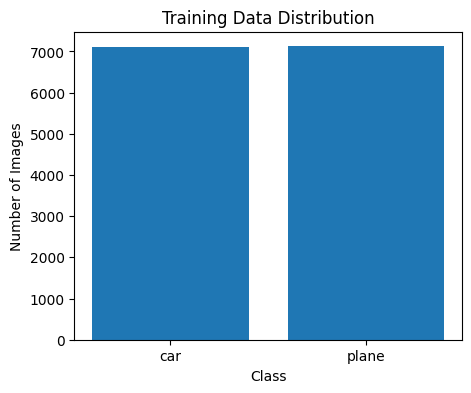

In [9]:
train_counts = {}

for cls in os.listdir(train_dir):
    train_counts[cls] = len(os.listdir(os.path.join(train_dir, cls)))

plt.figure(figsize=(5,4))
plt.bar(train_counts.keys(), train_counts.values())
plt.title("Training Data Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

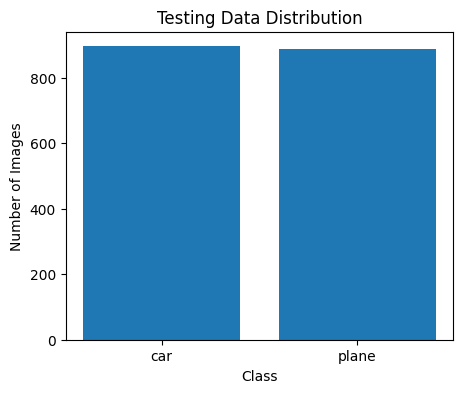

In [10]:
test_counts = {}

for cls in os.listdir(test_dir):
    test_counts[cls] = len(os.listdir(os.path.join(test_dir, cls)))

plt.figure(figsize=(5,4))
plt.bar(test_counts.keys(), test_counts.values())
plt.title("Testing Data Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

Seperti hasil pengecekan jumlah data diatas, dapat dilihat bahwa dataset pada train dan test seimbang sehingga tidak diperlukan processing lain untuk imbalance data.

## Cek RGB

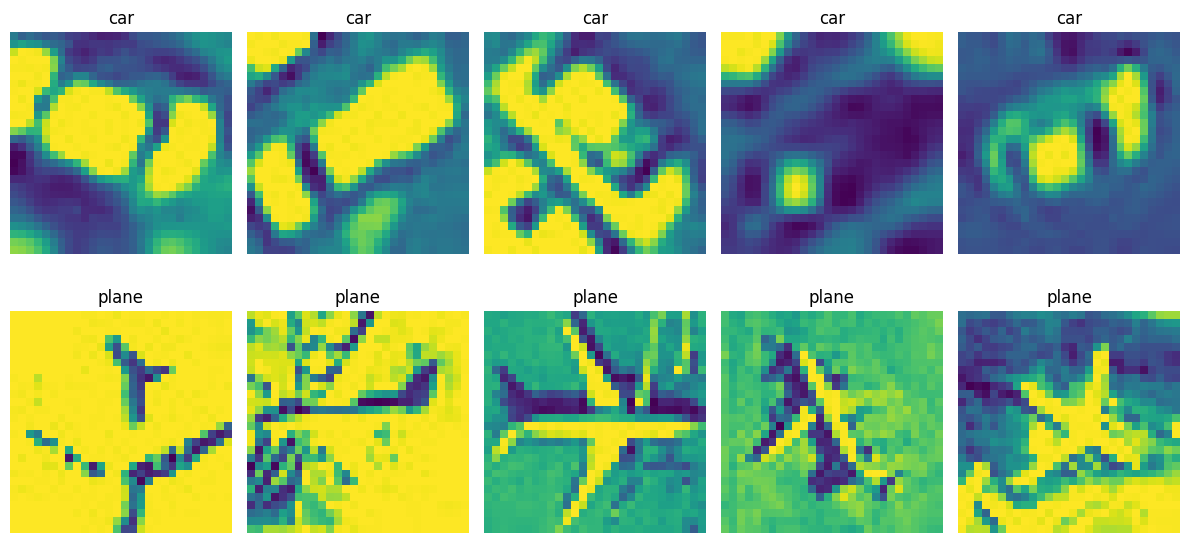

In [11]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(2,5, figsize=(12,6))

classes = os.listdir(train_dir)

for row, cls in enumerate(classes):

    images = os.listdir(os.path.join(train_dir, cls))
    samples = random.sample(images,5)

    for col, img_name in enumerate(samples):

        img_path = os.path.join(train_dir, cls, img_name)

        img = Image.open(img_path)

        axes[row,col].imshow(img)
        axes[row,col].set_title(cls)
        axes[row,col].axis("off")

plt.tight_layout()
plt.show()

In [12]:
modes = []

for cls in os.listdir(train_dir):

    folder = os.path.join(train_dir, cls)

    for img_name in os.listdir(folder):

        img = Image.open(os.path.join(folder, img_name))

        modes.append(img.mode)

print(set(modes))

{'L'}


Berdasarkan hasil visualisasi, gambar pada dataset tampak berwarna kuning, hijau, dan ungu. Warna tersebut bukan merupakan warna asli gambar, melainkan berasal dari colormap bawaan Matplotlib (viridis) yang secara otomatis digunakan saat menampilkan citra grayscale dengan plt.imshow(). Oleh karena itu, warna-warna tersebut hanya merepresentasikan perbedaan intensitas piksel, bukan informasi warna sebenarnya.

Hasil pemeriksaan mode gambar menunjukkan 'L' yang
artinya seluruh gambar berada dalam mode Luminance, yaitu grayscale 8-bit dengan satu channel. Setiap piksel hanya memiliki satu nilai intensitas pada rentang 0–255, di mana nilai 0 merepresentasikan warna hitam dan 255 merepresentasikan warna putih.

Karena seluruh dataset menggunakan mode L, proses preprocessing dan arsitektur GAN nantinya cukup menggunakan 1 input channel, bukan 3 channel seperti pada gambar RGB.

Path : /content/drive/MyDrive/DeepLearning_UAS/Train/car/62385.jpg
Class: car
Filename: 62385.jpg
Size: (28, 28)
Mode: L


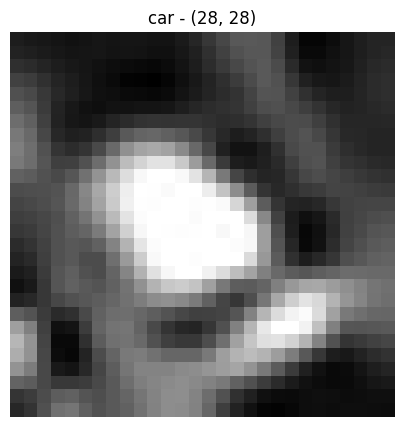

In [13]:
kelas = os.listdir(train_dir)[0]
folder = os.path.join(train_dir, kelas)
nama_file = os.listdir(folder)[0]

img_path = os.path.join(folder, nama_file)
img = Image.open(img_path)

print("Path :", img_path)
print("Class:", kelas)
print("Filename:", nama_file)
print("Size:", img.size)
print("Mode:", img.mode)

plt.figure(figsize=(5,5))
plt.imshow(img, cmap="gray")
plt.title(f"{kelas} - {img.size}")
plt.axis("off")
plt.show()

Ini adalah salah satu image pada dataset yang akan digunakan untuk training model. 

## Cek Size

In [14]:
sizes = []

for cls in os.listdir(train_dir):

    folder = os.path.join(train_dir, cls)

    for img_name in os.listdir(folder):

        img = Image.open(os.path.join(folder, img_name))

        sizes.append(img.size)

In [15]:
print(set(sizes))

{(28, 28)}


Hasil pengecekan menunjukkan bahwa semua gambar memiliki ukuran 28 × 28 piksel jadi gaperlu ada proses resize menyamakan sizes dari images.

## Cek Corrupt

In [16]:
train_dir = "/content/drive/MyDrive/DeepLearning_UAS/Train"

corrupt_files = []

for root, dirs, files in os.walk(train_dir):
    for file in files:
        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            img.verify()  # cek apakah file valid
        except:
            corrupt_files.append(path)

print(f"Jumlah file corrupt: {len(corrupt_files)}")

if len(corrupt_files) > 0:
    print("\nDaftar file corrupt:")
    for f in corrupt_files[:20]:
        print(f)

Jumlah file corrupt: 0


In [17]:
test_dir = "/content/drive/MyDrive/DeepLearning_UAS/Test"

corrupt_files = []

for root, dirs, files in os.walk(test_dir):
    for file in files:
        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            img.verify()  # cek apakah file valid
        except:
            corrupt_files.append(path)

print(f"Jumlah file corrupt: {len(corrupt_files)}")

if len(corrupt_files) > 0:
    print("\nDaftar file corrupt:")
    for f in corrupt_files[:20]:
        print(f)

Jumlah file corrupt: 0


## Distribusi Pixel

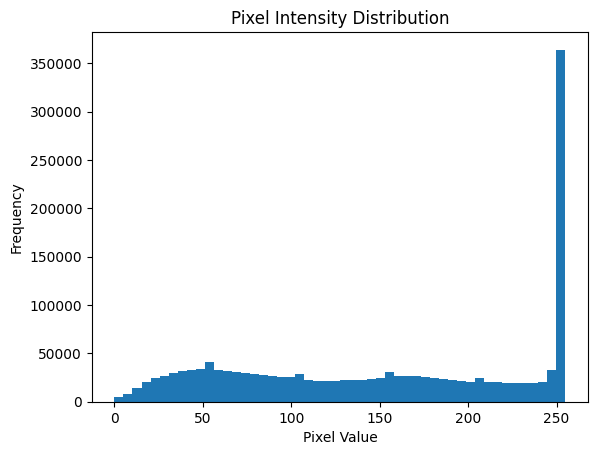

In [18]:
pixels = []

for cls in ['car','plane']:
    folder = os.path.join(train_dir, cls)

    for img_name in os.listdir(folder)[:1000]:
        img = Image.open(os.path.join(folder,img_name))
        pixels.extend(np.array(img).flatten())

plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

Distribusi intensitas piksel berada pada rentang 0–255 dengan puncak tertinggi di sekitar 255. Hal ini menandakan sebagian besar piksel pada dataset berwarna terang atau putih, sedangkan sisanya tersebar pada intensitas rendah hingga sedang yang merepresentasikan bentuk objek.

## Pola Umum Per class

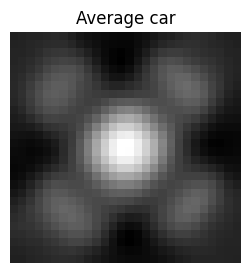

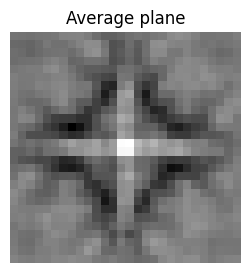

In [19]:
for cls in ["car","plane"]:

    imgs = []

    folder = os.path.join(train_dir, cls)

    for img_name in os.listdir(folder)[:1000]:
        img = Image.open(os.path.join(folder,img_name))
        imgs.append(np.array(img))

    avg_img = np.mean(imgs, axis=0)

    plt.figure(figsize=(3,3))
    plt.imshow(avg_img, cmap='gray')
    plt.title(f"Average {cls}")
    plt.axis('off')
    plt.show()

Berdasarkan average image, objek pada kelas car cenderung berada di bagian tengah gambar. Hal ini terlihat dari area tengah yang memiliki intensitas lebih tinggi dibandingkan bagian lainnya. Sementara itu, bagian pinggir tampak lebih gelap karena posisi objek tidak selalu menempati area tersebut. Hasil ini menunjukkan bahwa dataset memiliki pola penempatan objek yang relatif konsisten sehingga dapat membantu model GAN mempelajari distribusi gambar dengan lebih baik.

## Normalize

Dataset dinormalisasi dari rentang 0–255 menjadi −1 hingga 1 agar sesuai dengan output generator yang menggunakan aktivasi tanh. Kesamaan rentang nilai antara citra asli dan citra hasil generator membantu proses pelatihan CGAN menjadi lebih stabil dan mengurangi kemungkinan discriminator membedakan citra hanya berdasarkan perbedaan skala intensitas piksel.

In [20]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Embedding,
    Flatten,
    Concatenate,
    LeakyReLU,
    Reshape
)


In [21]:
# Hyperparameter untuk baseline

IMG_SIZE = 28
IMG_DIM = IMG_SIZE * IMG_SIZE
LATENT_DIM = 100
NUM_CLASSES = 2
BATCH_SIZE = 64

In [22]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    label_mode="int",
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    label_mode="int",
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 14240 files belonging to 2 classes.
Found 1784 files belonging to 2 classes.


In [23]:
for images, labels in train_ds.take(1):
    print(images.numpy().min())
    print(images.numpy().max())

0.0
255.0


In [24]:
for images, labels in test_ds.take(1):
    print(images.numpy().min())
    print(images.numpy().max())

0.0
255.0


In [25]:
def normalize(images, labels):
    images = (tf.cast(images, tf.float32) - 127.5) / 127.5
    return images, labels

train_ds = train_ds.map(normalize)
test_ds = test_ds.map(normalize)

In [26]:
for images, labels in train_ds.take(1):
    print(images.numpy().min())
    print(images.numpy().max())

-1.0
1.0


In [27]:
for images, labels in test_ds.take(1):
    print(images.numpy().min())
    print(images.numpy().max())

-1.0
1.0


# POIN B : Baseline


Diagram pada soal hanya menjelaskan urutan layer utama. Beberapa detail implementasi seperti Flatten, Concatenate, ukuran output Embedding, dan fungsi aktivasi tidak dijelaskan secara eksplisit. Oleh karena itu, implementasi menggunakan penyesuaian teknis yang diperlukan oleh TensorFlow/Keras tanpa mengubah urutan layer utama pada arsitektur yang diberikan.

Arsitektur baseline dibangun mengikuti rancangan yang diberikan pada soal tanpa perubahan pada struktur Generator maupun Discriminator. Model menggunakan mekanisme Conditional GAN (CGAN) dengan label embedding sehingga generator dapat menghasilkan citra sesuai kelas yang diinginkan. Model baseline ini kemudian dijadikan acuan untuk membandingkan performa setelah dilakukan modifikasi arsitektur dan tuning hyperparameter.

## Generator

Generator (Baseline cGAN)

Sesuai diagram:

•⁠  ⁠Embedding(labels)

•⁠  ⁠Linear(noise + n_labels, 128)

•⁠  ⁠Linear(128,256)

•⁠  ⁠Linear(256,512)

•⁠  ⁠Linear(512,1024)

•⁠  ⁠Linear(1024,img_size²)


In [28]:
# Generator
def build_generator():

    # Noise Input
    noise_input = Input(
        shape=(LATENT_DIM,),
        name="Noise_Input"
    )

    # Label Input
    label_input = Input(
        shape=(1,),
        dtype="int32",
        name="Label_Input"
    )

    # Embedding(labels)
    label_embedding = Embedding(
        input_dim=NUM_CLASSES,
        output_dim=NUM_CLASSES,
        name="Label_Embedding"
    )(label_input)
    label_embedding = Flatten()(label_embedding)

    # noise + labels
    x = Concatenate(name="Concatenate")(
        [noise_input, label_embedding]
    )

    # Linear(noise+n_labels,128)
    x = Dense(128, name="Linear_128")(x)
    x = LeakyReLU(0.2)(x)

    # Linear(128,256)
    x = Dense(256, name="Linear_256")(x)
    x = LeakyReLU(0.2)(x)

    # Linear(256,512)
    x = Dense(512, name="Linear_512")(x)
    x = LeakyReLU(0.2)(x)

    # Linear(512,1024)
    x = Dense(1024, name="Linear_1024")(x)
    x = LeakyReLU(0.2)(x)

    # Linear(1024,img_size²)
    x = Dense(
        IMG_DIM,
        activation="tanh",
        name="Output"
    )(x)

    output = Reshape(
        (IMG_SIZE, IMG_SIZE, 1),
        name="Generated_Image"
    )(x)
    model = Model(
        [noise_input, label_input],
        output,
        name="Generator"
    )
    return model
generator = build_generator()
generator.summary()


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Label_Input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Label_Embedding     │ (None, 1, 2)      │          4 │ Label_Input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Noise_Input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2)         │          0 │ Label_Embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Concatenate         │ (None, 102)       │          0 │ Noise_Input[0][0… │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Linear_128 (Dense)  │ (None, 128)       │     13,184 │ Concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128)       │          0 │ Linear_128[0][0]  │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Linear_256 (Dense)  │ (None, 256)       │     33,024 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 256)       │          0 │ Linear_256[0][0]  │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Linear_512 (Dense)  │ (None, 512)       │    131,584 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 512)       │          0 │ Linear_512[0][0]  │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Linear_1024 (Dense) │ (None, 1024)      │    525,312 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 1024)      │          0 │ Linear_1024[0][0] │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output (Dense)      │ (None, 784)       │    803,600 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Generated_Image     │ (None, 28, 28, 1) │          0 │ Output[0][0]      │
│ (Reshape)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,506,708 (5.75 MB)

 Trainable params: 1,506,708 (5.75 MB)

 Non-trainable params: 0 (0.00 B)

## Diskriminator

Discriminator menerima citra berukuran 28×28×1 sebagai input. Citra diproses menggunakan dua layer Conv2D dengan aktivasi LeakyReLU untuk mengekstraksi fitur. Hasil ekstraksi fitur kemudian di-flatten dan diteruskan ke layer Dense dengan satu neuron yang menghasilkan probabilitas apakah citra termasuk real atau fake.

In [29]:
def build_discriminator():
    # Image Input
    image_input = Input(
        shape=(IMG_SIZE, IMG_SIZE, 1),
        name="Image_Input"
    )
    x = Flatten()(image_input)
    # Label Input
    label_input = Input(
        shape=(1,),
        dtype="int32",
        name="Label_Input"
    )
    # Embedding(labels)
    label_embedding = Embedding(
        input_dim=NUM_CLASSES,
        output_dim=NUM_CLASSES,
        name="Label_Embedding"
    )(label_input)
    label_embedding = Flatten()(label_embedding)
    # img + labels
    x = Concatenate(name="Concatenate")(
        [x, label_embedding]
    )
    # Linear(n_labels+img_size²,512)
    x = Dense(512, name="Linear_512")(x)
    x = LeakyReLU(0.2)(x)

    # Linear(512,1024)
    x = Dense(1024, name="Linear_1024_1")(x)
    x = LeakyReLU(0.2)(x)

    # Linear(1024,1024)
    x = Dense(1024, name="Linear_1024_2")(x)
    x = LeakyReLU(0.2)(x)

    # Linear(1024,512)
    x = Dense(512, name="Linear_512_2")(x)
    x = LeakyReLU(0.2)(x)

    # Linear(512,1)
    output = Dense(
        1,
        activation="sigmoid",
        name="Output"
    )(x)
    model = Model(
        [image_input, label_input],
        output,
        name="Discriminator"
    )
    return model
discriminator = build_discriminator()
discriminator.summary()


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Label_Input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Image_Input         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Label_Embedding     │ (None, 1, 2)      │          4 │ Label_Input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 784)       │          0 │ Image_Input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 2)         │          0 │ Label_Embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Concatenate         │ (None, 786)       │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Linear_512 (Dense)  │ (None, 512)       │    402,944 │ Concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 512)       │          0 │ Linear_512[0][0]  │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Linear_1024_1       │ (None, 1024)      │    525,312 │ leaky_re_lu_4[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 1024)      │          0 │ Linear_1024_1[0]… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Linear_1024_2       │ (None, 1024)      │  1,049,600 │ leaky_re_lu_5[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 1024)      │          0 │ Linear_1024_2[0]… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Linear_512_2        │ (None, 512)       │    524,800 │ leaky_re_lu_6[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 512)       │          0 │ Linear_512_2[0][… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output (Dense)      │ (None, 1)         │        513 │ leaky_re_lu_7[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,503,173 (9.55 MB)

 Trainable params: 2,503,173 (9.55 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

Cross Entropy adalah fungsi loss yang digunakan untuk mengukur seberapa jauh prediksi model dari label yang sebenarnya.
Karena Discriminator tugasnya hanya menentukan Real (1) atau Fake (0), maka digunakan Binary Cross Entropy (BCE).

In [31]:
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

In [32]:
def generator_loss(fake_output):
    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )


def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss

Optimizer Adam dengan learning rate 0.0002 dan beta1 = 0.5 dipilih agar proses pelatihan lebih stabil.

## Train

In [33]:
@tf.function
def train_step(real_images, labels):

    batch_size = tf.shape(real_images)[0]

    # Generate random noise
    noise = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        # Generate fake images
        fake_images = generator([noise, labels], training=True)

        # Discriminator predictions
        real_output = discriminator(
            [real_images, labels],
            training=True
        )

        fake_output = discriminator(
            [fake_images, labels],
            training=True
        )

        # Loss
        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    # Compute gradients
    gradients_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # Update weights
    generator_optimizer.apply_gradients(
        zip(
            gradients_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

In [34]:
def train(dataset, epochs):
    gen_losses = []
    disc_losses = []

    for epoch in range(epochs):

        gen_loss_avg = 0
        disc_loss_avg = 0
        steps = 0

        for real_images, labels in dataset:

            g_loss, d_loss = train_step(
                real_images,
                labels
            )

            gen_loss_avg += g_loss
            disc_loss_avg += d_loss
            steps += 1

        gen_losses.append(gen_loss_avg / steps)
        disc_losses.append(disc_loss_avg / steps)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Generator Loss: {gen_loss_avg/steps:.4f} | "
            f"Discriminator Loss: {disc_loss_avg/steps:.4f}"
        )
    return gen_losses, disc_losses

Generator dan Discriminator dilatih secara bergantian pada setiap batch data. Generator menerima noise acak dan label kelas sebagai masukan untuk menghasilkan citra baru, sedangkan Discriminator mengevaluasi citra asli maupun citra hasil generasi. Setelah nilai loss dihitung, dilakukan proses backpropagation untuk memperoleh gradien, kemudian bobot kedua model diperbarui menggunakan optimizer Adam. Proses ini diulang pada setiap epoch hingga nilai Generator Loss dan Discriminator Loss menjadi lebih stabil, yang menunjukkan bahwa kedua model belajar secara seimbang.

In [35]:
gen_losses, disc_losses = train(train_ds, 40)

Epoch [1/40] Generator Loss: 2.4643 | Discriminator Loss: 0.4120
Epoch [2/40] Generator Loss: 3.2791 | Discriminator Loss: 0.4622
Epoch [3/40] Generator Loss: 3.6260 | Discriminator Loss: 0.4025
Epoch [4/40] Generator Loss: 3.6424 | Discriminator Loss: 0.3949
Epoch [5/40] Generator Loss: 3.6152 | Discriminator Loss: 0.3654
Epoch [6/40] Generator Loss: 3.5821 | Discriminator Loss: 0.3742
Epoch [7/40] Generator Loss: 3.7427 | Discriminator Loss: 0.3473
Epoch [8/40] Generator Loss: 3.7442 | Discriminator Loss: 0.3570
Epoch [9/40] Generator Loss: 3.6648 | Discriminator Loss: 0.3491
Epoch [10/40] Generator Loss: 3.9176 | Discriminator Loss: 0.4121
Epoch [11/40] Generator Loss: 3.4788 | Discriminator Loss: 0.3994
Epoch [12/40] Generator Loss: 3.5290 | Discriminator Loss: 0.3821
Epoch [13/40] Generator Loss: 3.5333 | Discriminator Loss: 0.3723
Epoch [14/40] Generator Loss: 3.7503 | Discriminator Loss: 0.3848
Epoch [15/40] Generator Loss: 3.9135 | Discriminator Loss: 0.3005
Epoch [16/40] Gener

## Visualisasi Hasil Generator

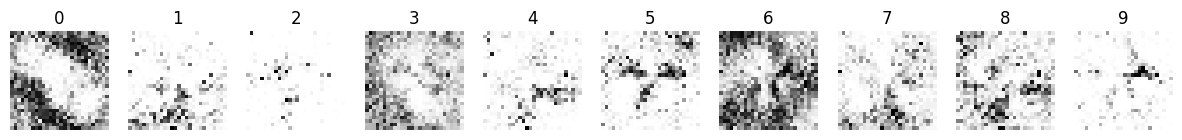

In [36]:
n = 10

noise = tf.random.normal((n, LATENT_DIM))
labels = tf.range(0, n)

generated = generator.predict([noise, labels], verbose=0)

generated = (generated + 1) / 2   # balik ke 0-1

plt.figure(figsize=(15,2))

for i in range(n):
    plt.subplot(1,10,i+1)
    plt.imshow(generated[i,:,:,0], cmap="gray")
    plt.title(f"{labels[i].numpy()}")
    plt.axis("off")

plt.show()

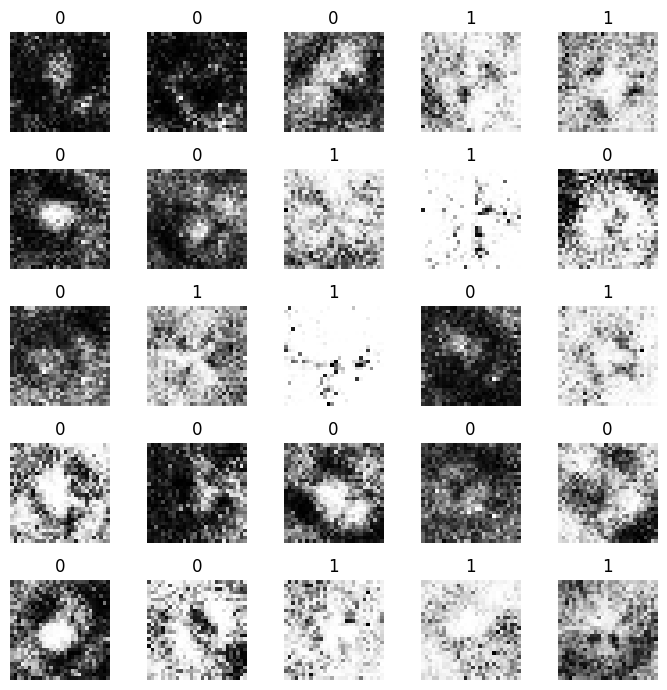

In [37]:
rows = 5
cols = 5

noise = tf.random.normal((rows*cols, LATENT_DIM))
labels = tf.random.uniform(
    (rows*cols,),
    minval=0,
    maxval=NUM_CLASSES,
    dtype=tf.int32
)

generated = generator.predict([noise, labels], verbose=0)
generated = (generated+1)/2

plt.figure(figsize=(7,7))

for i in range(rows*cols):
    plt.subplot(rows, cols, i+1)
    plt.imshow(generated[i,:,:,0], cmap="gray")
    plt.title(int(labels[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

Berdasarkan hasil visualisasi, model baseline masih menghasilkan banyak citra yang menyerupai noise sehingga bentuk objek belum dapat dikenali dengan baik. Sebagian besar gambar hanya menampilkan pola acak dan belum mampu membedakan karakteristik kelas car maupun plane.

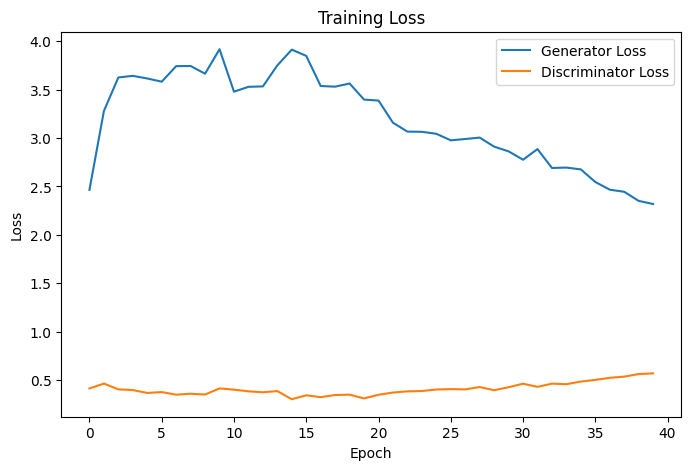

In [38]:
plt.figure(figsize=(8,5))

plt.plot(gen_losses,label="Generator Loss")
plt.plot(disc_losses,label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()

plt.show()

In [84]:
import numpy as np

best_epoch_base = np.argmin(gen_losses) + 1
best_gen_loss_base = np.min(gen_losses)
best_disc_loss_base = disc_losses[best_epoch_base - 1]

print("=== Baseline ===")
print("Best Epoch :", best_epoch_base)
print("Generator Loss :", float(best_gen_loss_base))
print("Discriminator Loss :", float(best_disc_loss_base))

=== Baseline ===
Best Epoch : 40
Generator Loss : 2.3177030086517334
Discriminator Loss : 0.5679970383644104


Dari grafik training loss diatas, dapat dilihat bahwa Generator Loss mengalami kenaikan pada awal proses pelatihan hingga mencapai sekitar 4, kemudian mulai menurun secara bertahap. Meskipun demikian, nilai loss generator hingga akhir training masih relatif tinggi (sekitar 2,3), yang menunjukkan bahwa generator masih belum mampu menghasilkan citra yang sepenuhnya menyerupai data asli.

Sementara itu, Discriminator Loss cenderung rendah dan stabil di kisaran 0,6 sepanjang proses pelatihan. Hal ini menunjukkan bahwa discriminator masih lebih unggul dalam membedakan citra asli dan citra hasil generator.

Kesimpulannya, generator belum mampu bersaing dengan kemampuan discriminator sehingga keseimbangan antara kedua model belum tercapai secara optimal.

## FID

InceptionV3 dipilih karena merupakan model pretrained yang dapat mengekstraksi fitur gambar dengan baik. FID menggunakan fitur dari InceptionV3 untuk mengukur seberapa dekat distribusi gambar hasil generator dengan distribusi gambar asli. Semakin kecil nilai FID, semakin mirip kualitas gambar yang dihasilkan dengan data asli.

Cara Kerja :
1. Mengambil gambar asli dari data test

mengambil gambar dari dataset test sebanyak 1.000 gambar. Gambar ini digunakan sebagai real images yang akan dibandingkan dengan gambar hasil generator saat menghitung nilai FID.

2. Menghasilkan gambar palsu

Program membuat 1.000 noise acak dan label kelas (car atau plane). Noise dan label tersebut dimasukkan ke Generator sehingga dihasilkan 1.000 fake images yang akan dievaluasi.

3. ⁠Menyesuaikan ukuran gambar

Karena InceptionV3 hanya menerima gambar berukuran 299×299, seluruh gambar diubah dari ukuran 28×28 menjadi 299×299

4.⁠ ⁠Mengubah grayscale menjadi RGB

Dataset yang digunakan berupa grayscale (1 channel), sedangkan InceptionV3 membutuhkan RGB (3 channel). Oleh karena itu gambar dikonversi menjadi tiga channel.

5. ⁠Preprocessing gambar

Sebelum masuk ke InceptionV3, gambar diproses menggunakan preprocess_input() agar format nilai piksel sesuai dengan standar model InceptionV3 yang telah dilatih pada ImageNet.

6. Ekstraksi fitur menggunakan InceptionV3

Program tidak langsung membandingkan gambar, tetapi menggunakan InceptionV3 untuk mengekstraksi fitur dari gambar asli dan gambar hasil generator. Fitur yang diperoleh berupa representasi visual seperti bentuk, tekstur, dan pola objek.

7. Menghitung FID

Fungsi calculate_fid() menghitung Frechet Inception Distance (FID) berdasarkan rata-rata (mean) dan kovarians dari fitur gambar asli dan gambar hasil generator. Nilai inilah yang digunakan sebagai ukuran kualitas model.


8. Print hasil

In [39]:
import numpy as np
import scipy.linalg

In [40]:
real_images = []

for images, labels in test_ds.take(16):
    real_images.append(images)

real_images = tf.concat(real_images, axis=0)
real_images = real_images[:1000]

In [41]:
num_images = 1000

noise = tf.random.normal((num_images, LATENT_DIM))

labels = tf.random.uniform(
    (num_images,),
    minval=0,
    maxval=NUM_CLASSES,
    dtype=tf.int32
)

fake_images = generator([noise, labels], training=False)

In [42]:
real_images = tf.image.resize(real_images, (299,299))
fake_images = tf.image.resize(fake_images, (299,299))

In [43]:
real_images = tf.image.grayscale_to_rgb(real_images)
fake_images = tf.image.grayscale_to_rgb(fake_images)

In [44]:
from tensorflow.keras.applications.inception_v3 import preprocess_input

real_images = preprocess_input(real_images * 127.5 + 127.5)
fake_images = preprocess_input(fake_images * 127.5 + 127.5)

In [45]:
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from scipy.linalg import sqrtm

inception_model = InceptionV3(
    include_top=False,
    weights='imagenet',
    pooling='avg'
)


def calculate_fid(real_features, fake_features):
    # Calculate means
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)

    # Calculate squared difference between means
    ssdiff = np.sum((mu1 - mu2)**2.0)

    # Calculate the square root of the product of covariance matrices
    covmean = sqrtm(sigma1.dot(sigma2))

    # Check for imaginary numbers, handle if present
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    # Calculate FID score
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

real_images_fid = []
for images, labels in test_ds.take(16): # 16 * 64 = 1024 images
    real_images_fid.append(images)
real_images_fid = tf.concat(real_images_fid, axis=0)[:1000]

num_images_fid = 1000
noise_fid = tf.random.normal((num_images_fid, LATENT_DIM))
labels_fid = tf.random.uniform(
    (num_images_fid,),
    minval=0,
    maxval=NUM_CLASSES,
    dtype=tf.int32
)
fake_images_fid = generator([noise_fid, labels_fid], training=False)

real_images_fid = tf.image.resize(real_images_fid, (299,299))
fake_images_fid = tf.image.resize(fake_images_fid, (299,299))

real_images_fid = tf.image.grayscale_to_rgb(real_images_fid)
fake_images_fid = tf.image.grayscale_to_rgb(fake_images_fid)

real_images_fid = preprocess_input(real_images_fid * 127.5 + 127.5)
fake_images_fid = preprocess_input(fake_images_fid * 127.5 + 127.5)

real_features = inception_model.predict(real_images_fid, verbose=0)
fake_features = inception_model.predict(fake_images_fid, verbose=0)

# Calculate FID
fid_score = calculate_fid(real_features, fake_features)

print("FID:", fid_score)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
FID: 302.88102934069354


Dari hasil pengujian diperoleh nilai FID sebesar 302.88. Karena pada metrik FID semakin kecil nilainya semakin baik, maka nilai tersebut menunjukkan bahwa distribusi gambar yang dihasilkan Generator masih cukup jauh dari distribusi gambar asli. Dengan kata lain, kualitas gambar yang dihasilkan masih dapat ditingkatkan melalui modifikasi arsitektur maupun tuning hyperparameter.

# POIN C : Reconstruct dan Tuning

Pada Modified V1, perubahan yang dilakukan adalah meningkatkan latent dimension dari 100 menjadi 128, menambahkan Batch Normalization pada setiap hidden layer Generator, Dropout sebesar 0,3 pada Discriminator, serta menurunkan learning rate menjadi 0,0001 agar proses training lebih stabil.

Dibandingkan dengan model baseline, perubahan tersebut membantu Generator menghasilkan variasi citra yang lebih baik, sementara Batch Normalization membuat proses pembelajaran lebih stabil dan Dropout mengurangi risiko overfitting pada Discriminator. Dengan demikian, keseimbangan antara Generator dan Discriminator menjadi lebih baik sehingga kualitas citra yang dihasilkan meningkat, yang ditunjukkan dengan nilai FID yang lebih rendah dibandingkan model baseline.

### V1

In [65]:
LATENT_DIM_MOD = 128
EPOCHS_MOD = 70
LR_MOD = 0.0001


#### Generator

In [66]:
from tensorflow.keras.layers import BatchNormalization

def build_generator_modified():

    noise_input = Input(
        shape=(LATENT_DIM_MOD,),
        name="Noise_Input_Mod"
    )

    label_input = Input(
        shape=(1,),
        dtype="int32",
        name="Label_Input_Mod"
    )

    label_embedding = Embedding(
        input_dim=NUM_CLASSES,
        output_dim=NUM_CLASSES
    )(label_input)

    label_embedding = Flatten()(label_embedding)

    x = Concatenate()([noise_input, label_embedding])

    x = Dense(128)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Dense(256)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Dense(512)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Dense(1024)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Dense(
        IMG_DIM,
        activation="tanh"
    )(x)

    output = Reshape(
        (IMG_SIZE, IMG_SIZE, 1)
    )(x)

    return Model(
        [noise_input, label_input],
        output,
        name="Generator_Modified"
    )

In [67]:
generator_mod = build_generator_modified()
generator_mod.summary()

Model: "Generator_Modified"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Label_Input_Mod     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 2)      │          4 │ Label_Input_Mod[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Noise_Input_Mod     │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 2)         │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 130)       │          0 │ Noise_Input_Mod[… │
│ (Concatenate)       │                   │            │ flatten_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 128)       │     16,768 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_20[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_24      │ (None, 128)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 256)       │     33,024 │ leaky_re_lu_24[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_21[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_25      │ (None, 256)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 512)       │    131,584 │ leaky_re_lu_25[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_22[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_26      │ (None, 512)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 1024)      │    525,312 │ leaky_re_lu_26[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_23[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_27      │ (None, 1024)      │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 784)       │    803,600 │ leaky_re_lu_27[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 28, 28, 1) │          0 │ dense_24[0][0]  

 Total params: 1,517,972 (5.79 MB)

 Trainable params: 1,514,132 (5.78 MB)

 Non-trainable params: 3,840 (15.00 KB)

#### Diskriminator

In [68]:
from tensorflow.keras.layers import Dropout

def build_discriminator_modified():

    image_input = Input(
        shape=(IMG_SIZE, IMG_SIZE,1),
        name="Image_Input_Mod"
    )

    x = Flatten()(image_input)

    label_input = Input(
        shape=(1,),
        dtype="int32",
        name="Label_Input_Mod"
    )

    label_embedding = Embedding(
        input_dim=NUM_CLASSES,
        output_dim=NUM_CLASSES
    )(label_input)

    label_embedding = Flatten()(label_embedding)

    x = Concatenate()([x, label_embedding])

    x = Dense(512)(x)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.3)(x)

    x = Dense(1024)(x)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.3)(x)

    x = Dense(1024)(x)
    x = LeakyReLU(0.2)(x)

    x = Dense(512)(x)
    x = LeakyReLU(0.2)(x)

    output = Dense(
        1,
        activation="sigmoid"
    )(x)

    return Model(
        [image_input, label_input],
        output,
        name="Discriminator_Modified"
    )

In [69]:
discriminator_mod = build_discriminator_modified()
discriminator_mod.summary()

Model: "Discriminator_Modified"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Label_Input_Mod     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Image_Input_Mod     │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 1, 2)      │          4 │ Label_Input_Mod[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_10          │ (None, 784)       │          0 │ Image_Input_Mod[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_11          │ (None, 2)         │          0 │ embedding_5[0][0] │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 786)       │          0 │ flatten_10[0][0], │
│ (Concatenate)       │                   │            │ flatten_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 512)       │    402,944 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_28      │ (None, 512)       │          0 │ dense_25[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 512)       │          0 │ leaky_re_lu_28[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 1024)      │    525,312 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_29      │ (None, 1024)      │          0 │ dense_26[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 1024)      │          0 │ leaky_re_lu_29[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 1024)      │  1,049,600 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_30      │ (None, 1024)      │          0 │ dense_27[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 512)       │    524,800 │ leaky_re_lu_30[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_31      │ (None, 512)       │          0 │ dense_28[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 1)         │        513 │ leaky_re_lu_31[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,503,173 (9.55 MB)

 Trainable params: 2,503,173 (9.55 MB)

 Non-trainable params: 0 (0.00 B)

#### Train

In [70]:
generator_optimizer_mod = tf.keras.optimizers.Adam(
    learning_rate=LR_MOD,
    beta_1=0.5
)

discriminator_optimizer_mod = tf.keras.optimizers.Adam(
    learning_rate=LR_MOD,
    beta_1=0.5
)

In [71]:
@tf.function
def train_step_modified(real_images, labels):

    batch_size = tf.shape(real_images)[0]

    noise = tf.random.normal(
        [batch_size, LATENT_DIM_MOD]
    )

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        fake_images = generator_mod(
            [noise, labels],
            training=True
        )

        real_output = discriminator_mod(
            [real_images, labels],
            training=True
        )

        fake_output = discriminator_mod(
            [fake_images, labels],
            training=True
        )

        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gradients_generator = gen_tape.gradient(
        gen_loss,
        generator_mod.trainable_variables
    )

    gradients_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator_mod.trainable_variables
    )

    generator_optimizer_mod.apply_gradients(
        zip(
            gradients_generator,
            generator_mod.trainable_variables
        )
    )

    discriminator_optimizer_mod.apply_gradients(
        zip(
            gradients_discriminator,
            discriminator_mod.trainable_variables
        )
    )

    return gen_loss, disc_loss

In [72]:
def train_modified(dataset, epochs):

    gen_losses = []
    disc_losses = []

    for epoch in range(epochs):

        gen_loss_avg = 0
        disc_loss_avg = 0
        steps = 0

        for real_images, labels in dataset:

            g_loss, d_loss = train_step_modified(
                real_images,
                labels
            )

            gen_loss_avg += g_loss
            disc_loss_avg += d_loss
            steps += 1

        gen_losses.append(gen_loss_avg / steps)
        disc_losses.append(disc_loss_avg / steps)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Generator Loss: {gen_loss_avg/steps:.4f} | "
            f"Discriminator Loss: {disc_loss_avg/steps:.4f}"
        )

    return gen_losses, disc_losses

In [73]:
gen_losses_mod, disc_losses_mod = train_modified(
    train_ds,
    EPOCHS_MOD
)

Epoch [1/70] Generator Loss: 1.6651 | Discriminator Loss: 0.8422
Epoch [2/70] Generator Loss: 1.4774 | Discriminator Loss: 0.9640
Epoch [3/70] Generator Loss: 1.3657 | Discriminator Loss: 0.9709
Epoch [4/70] Generator Loss: 1.2387 | Discriminator Loss: 1.0506
Epoch [5/70] Generator Loss: 1.1835 | Discriminator Loss: 1.0493
Epoch [6/70] Generator Loss: 1.0753 | Discriminator Loss: 1.1290
Epoch [7/70] Generator Loss: 1.0470 | Discriminator Loss: 1.1343
Epoch [8/70] Generator Loss: 1.0794 | Discriminator Loss: 1.0936
Epoch [9/70] Generator Loss: 1.2587 | Discriminator Loss: 1.0102
Epoch [10/70] Generator Loss: 1.3353 | Discriminator Loss: 0.9563
Epoch [11/70] Generator Loss: 1.3034 | Discriminator Loss: 0.9564
Epoch [12/70] Generator Loss: 1.3181 | Discriminator Loss: 0.9700
Epoch [13/70] Generator Loss: 1.3469 | Discriminator Loss: 0.9638
Epoch [14/70] Generator Loss: 1.3060 | Discriminator Loss: 1.0079
Epoch [15/70] Generator Loss: 1.2876 | Discriminator Loss: 0.9968
Epoch [16/70] Gener

In [83]:
best_epoch_mod1 = np.argmin(gen_losses_mod) + 1
best_gen_loss_mod1 = np.min(gen_losses_mod)
best_disc_loss_mod1 = disc_losses_mod[best_epoch_mod1 - 1]

print("=== Modified CGAN V1 ===")
print("Best Epoch :", best_epoch_mod1)
print("Generator Loss :", float(best_gen_loss_mod1))
print("Discriminator Loss :", float(best_disc_loss_mod1))

=== Modified CGAN V1 ===
Best Epoch : 7
Generator Loss : 1.0470473766326904
Discriminator Loss : 1.1343493461608887


Berdasarkan hasil training, Modified CGAN V1 mencapai performa terbaik pada epoch ke-7. Pada epoch tersebut, Generator Loss sebesar 1,0470, sedangkan Discriminator Loss sebesar 1,1343.

Nilai Generator Loss dan Discriminator Loss yang relatif berdekatan menunjukkan bahwa generator dan discriminator berada dalam kondisi yang cukup seimbang. Artinya, generator mulai mampu menghasilkan gambar yang cukup realistis sehingga discriminator tidak lagi dapat membedakan gambar asli dan gambar hasil generasi dengan mudah.

Namun, perlu diperhatikan bahwa best epoch berdasarkan loss belum tentu merupakan epoch dengan kualitas gambar terbaik. Pada model GAN, evaluasi akhir tetap lebih tepat menggunakan FID Score dan hasil visual gambar, karena tujuan utama GAN adalah menghasilkan citra yang menyerupai data asli, bukan sekadar memperoleh nilai loss yang paling kecil.

### Visualisasi Hasil Generator

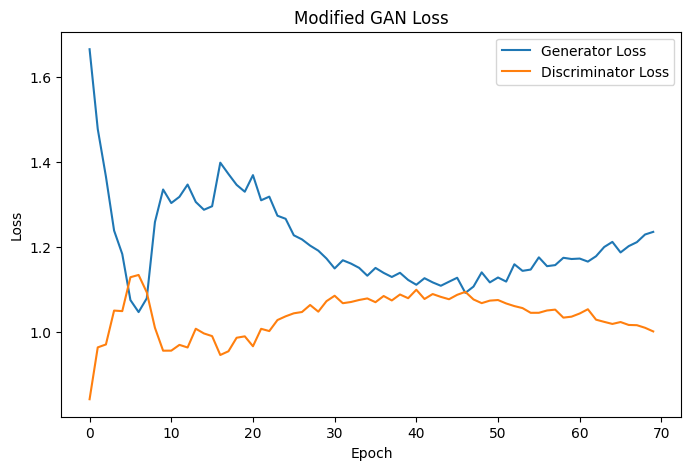

In [74]:
plt.figure(figsize=(8,5))

plt.plot(gen_losses_mod, label="Generator Loss")
plt.plot(disc_losses_mod, label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Modified GAN Loss")

plt.legend()

plt.show()

Pada awal training, Generator Loss cukup tinggi, kemudian menurun hingga sekitar epoch 40. Hal ini menunjukkan bahwa generator mulai belajar menghasilkan gambar yang semakin sulit dibedakan oleh discriminator.

Tapi di sisi lain, discriminator Loss pada awalnya rendah, kemudian meningkat dan akhirnya berada pada kisaran yang relatif stabil. Kondisi ini menunjukkan bahwa discriminator tidak lagi terlalu dominan seperti pada awal training karena generator mulai menghasilkan citra yang lebih realistis.

Setelah sekitar epoch 40, kedua kurva loss cenderung lebih stabil dan tidak mengalami perubahan yang ekstrem. Hal ini mengindikasikan bahwa proses adversarial antara generator dan discriminator mulai mencapai keseimbangan, sehingga proses pelatihan menjadi lebih stabil.

### FID

In [75]:
num_images = 25

noise = tf.random.normal((num_images, LATENT_DIM_MOD))

labels = tf.random.uniform(
    (num_images,),
    minval=0,
    maxval=NUM_CLASSES,
    dtype=tf.int32
)

fake_images = generator_mod(
    [noise, labels],
    training=False
)

In [76]:
num_images_fid = 1000
noise_fid = tf.random.normal((num_images_fid, LATENT_DIM_MOD))
labels_fid = tf.random.uniform(
    (num_images_fid,),
    minval=0,
    maxval=NUM_CLASSES,
    dtype=tf.int32
)

fake_images_fid = generator_mod(
    [noise_fid, labels_fid],
    training=False
)

In [77]:
real_images_for_mod_fid = []
for images, labels in test_ds.take(16): # 16 * 64 = 1024 images
    real_images_for_mod_fid.append(images)
real_images_for_mod_fid = tf.concat(real_images_for_mod_fid, axis=0)[:1000]

real_images_fid_mod = tf.image.resize(real_images_for_mod_fid, (299,299))
fake_images_fid_mod = tf.image.resize(fake_images_fid, (299,299))

real_images_fid_mod = tf.image.grayscale_to_rgb(real_images_fid_mod)
fake_images_fid_mod = tf.image.grayscale_to_rgb(fake_images_fid_mod)

real_images_fid_mod = preprocess_input(real_images_fid_mod * 127.5 + 127.5)
fake_images_fid_mod = preprocess_input(fake_images_fid_mod * 127.5 + 127.5)

real_features_mod = inception_model.predict(real_images_fid_mod, verbose=0)
fake_features_mod = inception_model.predict(fake_images_fid_mod, verbose=0)

fid_score_mod = calculate_fid(real_features_mod, fake_features_mod)

print("FID (Modified GAN):", fid_score_mod)

FID (Modified GAN): 265.3599878194512


Berdasarkan hasil evaluasi menggunakan Fréchet Inception Distance (FID), model baseline memperoleh nilai FID sebesar 301.88, sedangkan model hasil modifikasi memperoleh nilai 265.35. Karena nilai FID yang lebih rendah menunjukkan distribusi citra hasil generator semakin mendekati distribusi citra asli, maka dapat disimpulkan bahwa modifikasi arsitektur dan tuning hyperparameter berhasil meningkatkan kualitas citra yang dihasilkan. Penurunan FID menunjukkan bahwa generator mampu menghasilkan gambar yang lebih realistis dibandingkan model baseline.


Hal ini membaik disebabkan oleh
- Batch Normalization pada generator membuat proses pembelajaran lebih stabil sehingga generator menghasilkan gambar yang lebih konsisten.

- Dropout pada discriminator mencegah discriminator menjadi terlalu kuat sehingga generator memiliki kesempatan belajar lebih baik.

- ⁠Learning rate yang lebih kecil membuat pembaruan bobot lebih halus dan mengurangi ketidakstabilan selama training.

- Latent dimension yang lebih besar memberi generator kapasitas lebih untuk merepresentasikan variasi data.

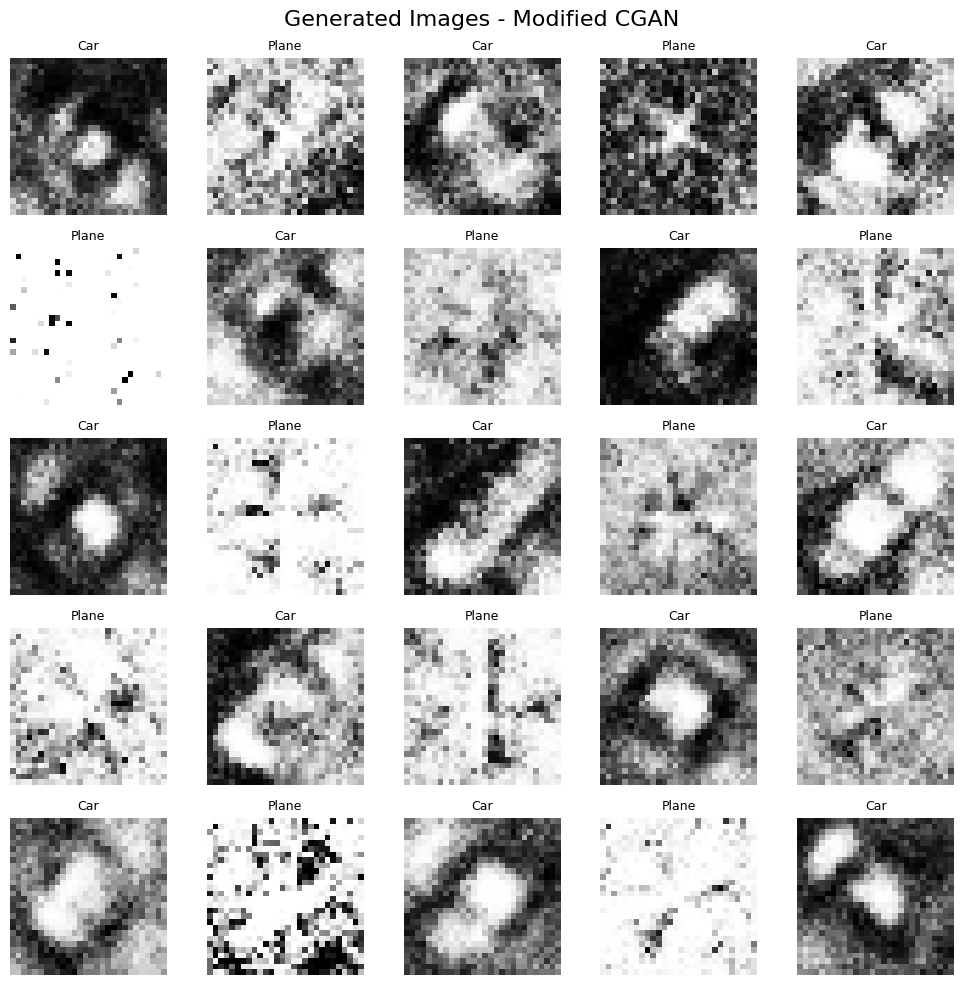

In [78]:
num_images = 25

noise = tf.random.normal((num_images, LATENT_DIM_MOD))

# Label: 0 = car, 1 = plane
labels = tf.constant(
    [0,1,0,1,0,
     1,0,1,0,1,
     0,1,0,1,0,
     1,0,1,0,1,
     0,1,0,1,0],
    dtype=tf.int32
)

generated_images = generator_mod(
    [noise, labels],
    training=False
)

generated_images = (generated_images + 1) / 2.0

plt.figure(figsize=(10,10))

for i in range(num_images):

    plt.subplot(5,5,i+1)

    plt.imshow(
        generated_images[i, :, :, 0],
        cmap="gray"
    )

    plt.title(
        "Car" if labels[i] == 0 else "Plane",
        fontsize=9
    )

    plt.axis("off")

plt.suptitle("Generated Images - Modified CGAN", fontsize=16)

plt.tight_layout()

plt.show()

Setelah dilakukan modifikasi pada Modified CGAN V1, kualitas citra mengalami peningkatan. Bentuk objek mulai terlihat lebih jelas dibandingkan baseline, meskipun masih terdapat noise dan beberapa gambar belum sepenuhnya menyerupai data asli. Pada beberapa sampel, karakteristik kendaraan dan pesawat sudah mulai terbentuk sehingga menunjukkan bahwa Generator mampu mempelajari distribusi data dengan lebih baik.

In [79]:
import pandas as pd
improvement = ((fid_score - fid_score_mod) / fid_score) * 100

results = pd.DataFrame({
    "Model": [
        "Baseline CGAN",
        "Modified CGAN V1"
    ],
    "Epoch": [
        50,
        50
    ],
    "FID": [
        round(fid_score, 2),
        round(fid_score_mod, 2)
    ]
})

results["Improvement (%)"] = [
    "-",
    f"{improvement:.2f}%"
]

results

,Model,Epoch,FID,Improvement (%)
0,Baseline CGAN,50,302.88,-
1,Modified CGAN V1,50,265.36,12.39%


(baseline 40 epoch dan modified 70 tetapi typo)

# Penjelasan

### Baseline compared to Modified CGAN V1

Batch Normalization membantu menstabilkan proses pembelajaran Generator, sedangkan Dropout mengurangi overfitting pada Discriminator sehingga keseimbangan antara kedua model menjadi lebih baik. Hasilnya, nilai FID menurun dibandingkan baseline, yang menunjukkan bahwa kualitas citra hasil generator menjadi lebih mendekati distribusi data asli.

### Best Model

Berdasarkan seluruh eksperimen yang telah saya lakukan, modified model memiliki performa yang paling stabil dan penurunannya sekitar 12.39% daripada baseline.

Berdasarkan hasil evaluasi menggunakan Fréchet Inception Distance (FID), *Modified CGAN* dipilih sebagai model terbaik karena memperoleh nilai FID yang lebih rendah dibandingkan model baseline, yaitu *265.36* dibandingkan *302.88*. Nilai FID yang lebih kecil menunjukkan bahwa distribusi citra hasil generator lebih mendekati distribusi data asli.

Perbaikan tersebut diperoleh melalui kombinasi modifikasi arsitektur dan tuning hyperparameter, yaitu penambahan *Batch Normalization* pada Generator, *Dropout* pada Discriminator, peningkatan *latent dimension* menjadi 128, penambahan epoch dari 40 menjadi 70, serta penurunan *learning rate* menjadi 0.0001. Kombinasi perubahan tersebut membuat proses training lebih stabil sehingga Generator mampu menghasilkan citra dengan kualitas yang lebih baik dibandingkan model baseline.

## Eksperimen

Pada Modified CGAN V2, arsitektur dikembangkan dengan meningkatkan latent dimension dari 128 menjadi 256 serta memperbesar ukuran label embedding dari 2 menjadi 32 agar Generator memperoleh informasi yang lebih kaya dari noise maupun label kelas. Selain itu, Batch Normalization tetap digunakan pada setiap hidden layer Generator untuk menjaga kestabilan proses training.

Pada Discriminator, nilai Dropout ditingkatkan dari 0,3 menjadi 0,4 untuk mengurangi risiko overfitting. Selain itu, learning rate Generator dipertahankan sebesar 0,0001, sedangkan learning rate Discriminator diturunkan menjadi 0,00005 agar proses pembelajaran Discriminator lebih lambat dan tidak terlalu mendominasi Generator selama training.

### Generator

In [85]:
LATENT_DIM_MOD2 = 256
EPOCHS_MOD2 = 70
LR_GEN = 0.0001
LR_DISC = 0.00005

In [86]:
def build_generator_modified_v2():

    noise_input = Input(shape=(LATENT_DIM_MOD2,))
    label_input = Input(shape=(1,), dtype="int32")

    label_embedding = Embedding(
        NUM_CLASSES,
        32          # lebih besar dari baseline
    )(label_input)

    label_embedding = Flatten()(label_embedding)

    x = Concatenate()([noise_input, label_embedding])

    for units in [256,512,1024]:
        x = Dense(units)(x)
        x = BatchNormalization(momentum=0.8)(x)
        x = LeakyReLU(0.2)(x)

    x = Dense(
        IMG_DIM,
        activation="tanh"
    )(x)

    output = Reshape((IMG_SIZE,IMG_SIZE,1))(x)

    return Model(
        [noise_input,label_input],
        output
    )

In [88]:
generator_v2 = build_generator_modified_v2()
generator_v2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 1, 32)     │         64 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_12          │ (None, 32)        │          0 │ embedding_6[0][0] │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 288)       │          0 │ input_layer_1[0]… │
│ (Concatenate)       │                   │            │ flatten_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 256)       │     73,984 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_30[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_32      │ (None, 256)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 512)       │    131,584 │ leaky_re_lu_32[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_31[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_33      │ (None, 512)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 1024)      │    525,312 │ leaky_re_lu_33[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_32[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_34      │ (None, 1024)      │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 784)       │    803,600 │ leaky_re_lu_34[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 28, 28, 1) │          0 │ dense_33[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,541,712 (5.88 MB)

 Trainable params: 1,538,128 (5.87 MB)

 Non-trainable params: 3,584 (14.00 KB)

### Diskriminator

In [89]:
def build_discriminator_modified_v2():

    image_input = Input(shape=(IMG_SIZE,IMG_SIZE,1))

    x = Flatten()(image_input)

    label_input = Input(shape=(1,),dtype="int32")

    label_embedding = Embedding(
        NUM_CLASSES,
        32
    )(label_input)

    label_embedding = Flatten()(label_embedding)

    x = Concatenate()([x,label_embedding])

    x = Dense(512)(x)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.4)(x)

    x = Dense(1024)(x)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.4)(x)

    output = Dense(
        1,
        activation="sigmoid"
    )(x)

    return Model(
        [image_input,label_input],
        output
    )

In [90]:
discriminator_v2 = build_discriminator_modified_v2()
discriminator_v2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 1, 32)     │         64 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_13          │ (None, 784)       │          0 │ input_layer_3[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_14          │ (None, 32)        │          0 │ embedding_7[0][0] │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 816)       │          0 │ flatten_13[0][0], │
│ (Concatenate)       │                   │            │ flatten_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 512)       │    418,304 │ concatenate_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_35      │ (None, 512)       │          0 │ dense_34[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 512)       │          0 │ leaky_re_lu_35[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 1024)      │    525,312 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_36      │ (None, 1024)      │          0 │ dense_35[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 1024)      │          0 │ leaky_re_lu_36[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 1)         │      1,025 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 944,705 (3.60 MB)

 Trainable params: 944,705 (3.60 MB)

 Non-trainable params: 0 (0.00 B)

### Train

In [91]:
generator_optimizer_mod2 = tf.keras.optimizers.Adam(
    learning_rate=LR_GEN,
    beta_1=0.5
)

discriminator_optimizer_mod2 = tf.keras.optimizers.Adam(
    learning_rate=LR_DISC,
    beta_1=0.5
)

In [93]:
def generator_loss(fake_output):
    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )


def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    total_loss = real_loss + fake_loss

    return total_loss

In [94]:
generator_mod2 = build_generator_modified_v2()
discriminator_mod2 = build_discriminator_modified_v2()

In [95]:
@tf.function
def train_step_modified_v2(real_images, labels):

    batch_size = tf.shape(real_images)[0]

    noise = tf.random.normal(
        [batch_size, LATENT_DIM_MOD2]
    )

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        fake_images = generator_mod2(
            [noise, labels],
            training=True
        )

        real_output = discriminator_mod2(
            [real_images, labels],
            training=True
        )

        fake_output = discriminator_mod2(
            [fake_images, labels],
            training=True
        )

        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gradients_generator = gen_tape.gradient(
        gen_loss,
        generator_mod2.trainable_variables
    )

    gradients_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator_mod2.trainable_variables
    )

    generator_optimizer_mod2.apply_gradients(
        zip(
            gradients_generator,
            generator_mod2.trainable_variables
        )
    )

    discriminator_optimizer_mod2.apply_gradients(
        zip(
            gradients_discriminator,
            discriminator_mod2.trainable_variables
        )
    )

    return gen_loss, disc_loss

In [96]:
def train_modified_v2(dataset, epochs):

    gen_losses = []
    disc_losses = []

    for epoch in range(epochs):

        gen_loss_avg = 0
        disc_loss_avg = 0
        steps = 0

        for real_images, labels in dataset:

            g_loss, d_loss = train_step_modified_v2(
                real_images,
                labels
            )

            gen_loss_avg += g_loss
            disc_loss_avg += d_loss
            steps += 1

        gen_losses.append(gen_loss_avg / steps)
        disc_losses.append(disc_loss_avg / steps)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Generator Loss: {gen_loss_avg/steps:.4f} | "
            f"Discriminator Loss: {disc_loss_avg/steps:.4f}"
        )

    return gen_losses, disc_losses

In [ ]:
gen_losses_mod2, disc_losses_mod2 = train_modified_v2(
    train_ds,
    EPOCHS_MOD2
)

Epoch [1/70] Generator Loss: 0.8871 | Discriminator Loss: 1.1729
Epoch [2/70] Generator Loss: 1.1408 | Discriminator Loss: 1.1040
Epoch [3/70] Generator Loss: 0.9275 | Discriminator Loss: 1.3081
Epoch [4/70] Generator Loss: 0.7952 | Discriminator Loss: 1.3429
Epoch [5/70] Generator Loss: 0.8145 | Discriminator Loss: 1.3069
Epoch [6/70] Generator Loss: 0.8017 | Discriminator Loss: 1.3690
Epoch [7/70] Generator Loss: 0.7933 | Discriminator Loss: 1.3559
Epoch [8/70] Generator Loss: 0.7591 | Discriminator Loss: 1.3664
Epoch [9/70] Generator Loss: 0.7609 | Discriminator Loss: 1.3729
Epoch [10/70] Generator Loss: 0.7538 | Discriminator Loss: 1.3858
Epoch [11/70] Generator Loss: 0.7553 | Discriminator Loss: 1.3728
Epoch [12/70] Generator Loss: 0.7452 | Discriminator Loss: 1.3709
Epoch [13/70] Generator Loss: 0.7405 | Discriminator Loss: 1.3978
Epoch [14/70] Generator Loss: 0.7300 | Discriminator Loss: 1.3893
Epoch [15/70] Generator Loss: 0.7293 | Discriminator Loss: 1.3803
Epoch [16/70] Gener

Karena keseimbangan antara Generator Loss dan Discriminator Loss tidak kunjung membaik, saya akan mengehentikan percobaan ini. Mungkin model ini gagal mendeketeksi karena memiliki arsitektur yang sangat kompleks (jika dibandingkan dengan Baseline dan Modified 1) sehingga model tidak belajar dengan optimal.

Kemungkinan penambahan latent dimension, embedding, dan Dropout yang lebih besar membuat proses training menjadi kurang seimbang sehingga Generator belum mampu menghasilkan citra yang lebih baik dibandingkan Modified CGAN V1. Oleh karena itu, Modified CGAN V1 tetap menjadi model dengan performa terbaik berdasarkan nilai FID yang diperoleh.


